# 88 - Code Challenge: Letters to Numbers

**Section:** Transfer Learning | **Prereqs:** `Transfer Learning/Pretraining_with_AutoEncoders.ipynb` | **Next:** `Autoencoders/Latent_Code_Of_MNIST.ipynb`

Train a CNN on EMNIST letters (26 classes), then transfer its **convolutional
stack** to a digit classifier (10 classes) and train only the new head.

**The cleanest transfer in this section**, because the model is deliberately
split into two named parts:

```python
self.conv   = nn.Sequential(...)   # transferable - generic stroke features
self.layers = nn.Sequential(...)   # task-specific - 26 classes vs 10
```

That structure makes the transfer two lines: copy `conv`, freeze it, replace
`layers`. Design your models this way when you expect to transfer them.

**Why letters transfer to digits.** Both are handwritten strokes in the same
28x28 format - curves, lines, junctions, terminals. Only the final mapping from
strokes to symbols differs, and that lives entirely in the head.

**The pieces to take away**
- `letters_model.conv.state_dict()` / `MNIST_Model.conv.load_state_dict(...)` -
  partial transfer between two different classes with a matching submodule.
- `torch.equal` on every parameter to prove the copy worked.
- `filter(lambda p: p.requires_grad, ...)` so the optimizer only holds trainable
  parameters.
- The L1 penalty summed over trainable parameters only - correct, since a frozen
  parameter's penalty is a constant that cannot affect any gradient.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

import torchvision
from torchsummary import summary

%matplotlib inline

In [2]:
# Both datasets: EMNIST letters (26 classes) and MNIST digits (10). Same 28x28
# greyscale format, which is what makes the transfer possible at all.
data_letters = torchvision.datasets.EMNIST(root='/', download=True, split="letters", train=True)
test_letter = torchvision.datasets.EMNIST(root='/', download=True, split="letters", train=False)

data_numbers = torchvision.datasets.MNIST(root='/', download=True, train=True)
test_numbers = torchvision.datasets.MNIST(root='/', download=True, train=False)

100%|██████████| 562M/562M [00:02<00:00, 233MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 26.6MB/s]


In [3]:
data_letters.data.unsqueeze(1).shape

torch.Size([124800, 1, 28, 28])

In [4]:
# Drop the placeholder class; labels are shifted by -1 to give indices 0-25.
categories = data_letters.classes
categories = categories[1:]
categories

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

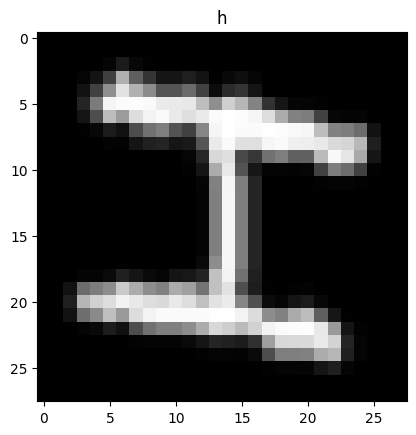

In [5]:
# An EMNIST sample - note the sideways orientation quirk (see CNNs/EMNIST.ipynb).
plt.imshow(data_letters.data[228], cmap='gray')
plt.title(categories[data_letters.targets[228] - 1]);

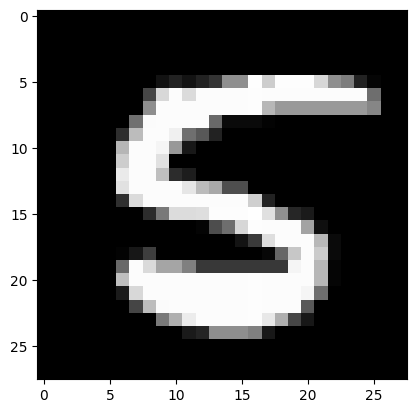

In [6]:
plt.imshow(data_numbers.data[2281], cmap='gray')

#### Donot use torch.tensor() for a tensor already

❌ letter_tensor_train = torch.tensor(data_letters.data.unsqueeze(1).detach().clone(), dtype=torch.float, device=device)

❌ never do ⬆️

In [7]:
# .unsqueeze(1) adds the channel axis. As the markdown above warns, use
# .clone().detach() on an existing tensor rather than torch.tensor(t), which
# copies and warns.
# Dividing into train, val sets for letters

device = ('cuda' if torch.cuda.is_available() else 'cpu')

letter_tensor_train = data_letters.data.unsqueeze(1).detach().clone().to(dtype=torch.float, device=device)
letter_labels_train = data_letters.targets.clone().detach().to(dtype=torch.long, device=device)

letter_tensor_val   = test_letter.data.unsqueeze(1).detach().clone().to(dtype=torch.float, device=device)
letter_labels_val   = test_letter.targets.clone().detach().to(dtype=torch.long, device=device)

In [8]:
# Labels shifted by -1 at Dataset construction, so classes are 0-25.
train_dataset = TensorDataset(letter_tensor_train, letter_labels_train - 1)
val_dataset = TensorDataset(letter_tensor_val, letter_labels_val - 1)

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0], shuffle=True, drop_last=True)

In [9]:
# The architecture, deliberately split in two:
#   self.conv   - convolutional feature extractor (the transferable part),
#   self.layers - classifier head (task-specific, 26 outputs).
# That split is what makes the transfer below two lines. Structure any model you
# expect to transfer this way.
# CNN model for Letter Recoginition
class EMNIST(nn.Module):
  def __init__(self) :
    super().__init__()
    '''
    Conv → BN → ReLU → Pool
    Raw features → normalize → activate → downsample
    (stable, standard, paper-recommended)
  '''

    self.conv = nn.Sequential(
        nn.Conv2d(1,64,kernel_size=3,padding=1,stride=1), # Ouput -> [64,28,28]
        nn.BatchNorm2d(64), # BatchNorm take input channels
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [64,14,14]

        nn.Conv2d(64,128, kernel_size=3, padding=1, stride=1), # Output -> [128,14,14]
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [128,7,7]

        nn.Flatten()
    )

    self.layers = nn.Sequential(
        nn.Linear(128*7*7, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512,26)
    )

  def forward(self,x):
    return self.layers(self.conv(x))

In [10]:
test_model = EMNIST().to(device)
test_model

EMNIST(
  (conv): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (layers): Sequential(
    (0): Linear(in_features=6272, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=512, out_features=26, bias=True)
  )
)

In [11]:
# torchsummary.
summary(test_model, input_size=(1,28,28), batch_size=256)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [256, 64, 28, 28]             640
       BatchNorm2d-2          [256, 64, 28, 28]             128
         LeakyReLU-3          [256, 64, 28, 28]               0
         AvgPool2d-4          [256, 64, 14, 14]               0
            Conv2d-5         [256, 128, 14, 14]          73,856
       BatchNorm2d-6         [256, 128, 14, 14]             256
         LeakyReLU-7         [256, 128, 14, 14]               0
         AvgPool2d-8           [256, 128, 7, 7]               0
           Flatten-9                [256, 6272]               0
           Linear-10                 [256, 512]       3,211,776
             ReLU-11                 [256, 512]               0
          Dropout-12                 [256, 512]               0
           Linear-13                  [256, 26]          13,338
Total params: 3,299,994
Trainable param

In [12]:
# Training the letters model: AdamW with weight decay, plus an L1 penalty.
def train_model_letters():

  model = EMNIST().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10
  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 1e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [13]:
# Train on 26-class EMNIST.
letters_model, letters_losses, letters_train_acc, letters_val_acc = train_model_letters()

Epoch 0 | Loss : 0.7679 | Train Acc 77.8386459350586 | Val Acc : 89.3125
Epoch 9 | Loss : 0.1637 | Train Acc 94.44462585449219 | Val Acc : 94.10096740722656


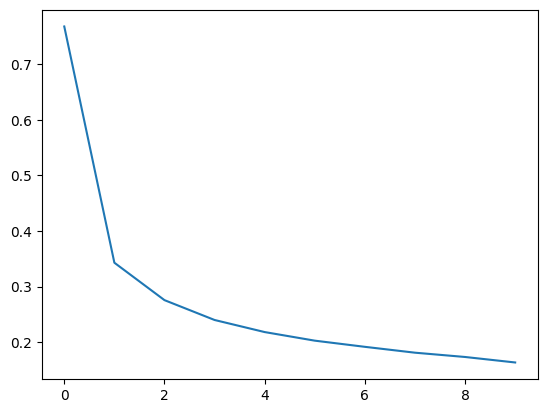

In [14]:
# Loss curve.
plt.plot(letters_losses);

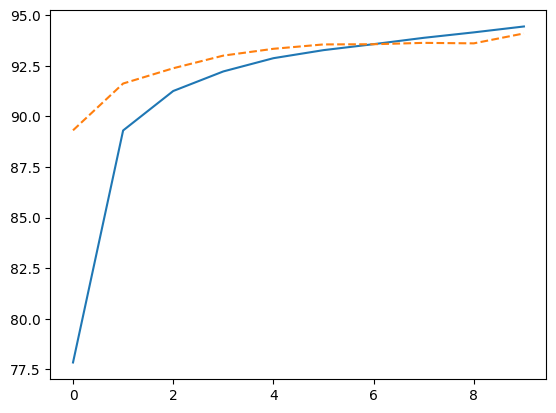

In [15]:
# Train and validation accuracy on letters.
plt.plot(letters_train_acc)
plt.plot(letters_val_acc ,'--');

## Now we transfer to the MNIST model. We will not train the conv part only the linear layers

In [16]:
# The digit model: IDENTICAL conv block, head changed to 10 outputs.
# The conv block must match exactly for load_state_dict to accept the weights.
# CNN model for MNIST Recoginition
class MNIST(nn.Module):
  def __init__(self) :
    super().__init__()
    '''
    Conv → BN → ReLU → Pool
    Raw features → normalize → activate → downsample
    (stable, standard, paper-recommended)
  '''

    self.conv = nn.Sequential(
        nn.Conv2d(1,64,kernel_size=3,padding=1,stride=1), # Ouput -> [64,28,28]
        nn.BatchNorm2d(64), # BatchNorm take input channels
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [64,14,14]

        nn.Conv2d(64,128, kernel_size=3, padding=1, stride=1), # Output -> [128,14,14]
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [128,7,7]

        nn.Flatten()
    )

    self.layers = nn.Sequential(
        nn.Linear(128*7*7, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512,10) # CHange for MNIST 10 classes
    )

  def forward(self,x):
    return self.layers(self.conv(x))

In [17]:
test_model = MNIST().to(device)
test_model

MNIST(
  (conv): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (layers): Sequential(
    (0): Linear(in_features=6272, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [18]:
# torchsummary for the digit model.
summary(test_model, input_size=(1,28,28), batch_size=256)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [256, 64, 28, 28]             640
       BatchNorm2d-2          [256, 64, 28, 28]             128
         LeakyReLU-3          [256, 64, 28, 28]               0
         AvgPool2d-4          [256, 64, 14, 14]               0
            Conv2d-5         [256, 128, 14, 14]          73,856
       BatchNorm2d-6         [256, 128, 14, 14]             256
         LeakyReLU-7         [256, 128, 14, 14]               0
         AvgPool2d-8           [256, 128, 7, 7]               0
           Flatten-9                [256, 6272]               0
           Linear-10                 [256, 512]       3,211,776
             ReLU-11                 [256, 512]               0
          Dropout-12                 [256, 512]               0
           Linear-13                  [256, 10]           5,130
Total params: 3,291,786
Trainable param

In [19]:
# MNIST tensors on the GPU.
tensor_train = data_numbers.data.unsqueeze(1).detach().clone().to(dtype=torch.float, device=device)
labels_train = data_numbers.targets.clone().detach().to(dtype=torch.long, device=device)

tensor_val   = test_numbers.data.unsqueeze(1).detach().clone().to(dtype=torch.float, device=device)
labels_val   = test_numbers.targets.clone().detach().to(dtype=torch.long, device=device)

In [20]:
MNIST_train_dataset = TensorDataset(tensor_train, labels_train)
MNIST_val_dataset = TensorDataset(tensor_val, labels_val)

bs = 256
MNIST_train_loader = DataLoader(MNIST_train_dataset, batch_size=bs, shuffle=True, drop_last=True)
MNIST_val_loader = DataLoader(MNIST_val_dataset, batch_size=MNIST_val_dataset.tensors[0].shape[0], shuffle=True, drop_last=True)

In [21]:
# THE TRANSFER, in four lines:
#   copy the conv weights across,
#   freeze conv,
#   leave layers trainable.
# Note only `conv` is transferred - the head is left randomly initialised,
# because a 26-class head cannot map onto 10 classes and its weights mean
# nothing for digits.
# 1. Copy weights efficiently
MNIST_Model = MNIST()

conv_state = letters_model.conv.state_dict()
MNIST_Model.conv.load_state_dict(conv_state)

# 2. Freeze those layers explicitly
for param in MNIST_Model.conv.parameters():
    param.requires_grad = False

for param in MNIST_Model.layers.parameters():
    param.requires_grad = True

In [22]:
# Verify the copy tensor by tensor with torch.equal. Do this every time.
## Checking if the models weights are same

for target,source in zip(MNIST_Model.conv.parameters(), letters_model.conv.parameters()):
  if torch.equal(target.data,source.data.cpu()):
    print("Target and Source are equal !!")
  else: print("Target and Source are not equal!!")

Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!


In [23]:
# What the optimizer will actually see: only the head's parameters.
a = filter(lambda p: p.requires_grad, MNIST_Model.parameters())
for i in a:
  print(i.requires_grad)

True
True
True
True


In [24]:
# Confirming the conv layers are frozen (False) and the head is not (True).
# Checking if the MNIST_model conv layers are frozzen

for params in MNIST_Model.parameters():
  print(params.requires_grad)

False
False
False
False
False
False
False
False
True
True
True
True


In [25]:
# Training the head only.
# filter(lambda p: p.requires_grad, ...) passes just the trainable parameters.
# The L1 sum also runs over trainable parameters only - correct, since a frozen
# parameter's penalty is a constant and contributes no gradient.
def train_model_mnist():

  # The model is already initialized and conv layers are frozen
  model = MNIST_Model.to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10

  # Only optimize parameters that require gradients (i.e., the unfrozen linear layers)
  optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.05,
    betas=(0.9, 0.999)
  )

  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 1e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in MNIST_train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of trainable parameters
      # only summing over parameters that require gradients
      l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
      num_trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
      if num_trainable_parameters > 0:
          loss = loss + l1_lambda * (l1_norm / num_trainable_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(MNIST_val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [26]:
# Train. This should reach high accuracy in very few epochs: the features were
# already there, only the mapping from strokes to digits had to be learned.
mnist_model_trained, mnist_losses, mnist_train_acc, mnist_val_acc = train_model_mnist()

Epoch 0 | Loss : 0.1952 | Train Acc 95.37259674072266 | Val Acc : 98.4000015258789
Epoch 9 | Loss : 0.0194 | Train Acc 99.47248840332031 | Val Acc : 99.29000091552734


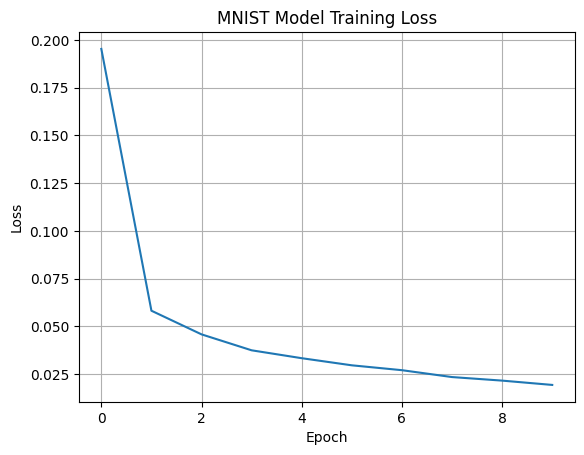

In [27]:
# Loss curve - note where it starts, far below a from-scratch run.
plt.plot(mnist_losses);
plt.title('MNIST Model Training Loss');
plt.xlabel('Epoch');
plt.ylabel('Loss');
plt.grid(True);
plt.show();

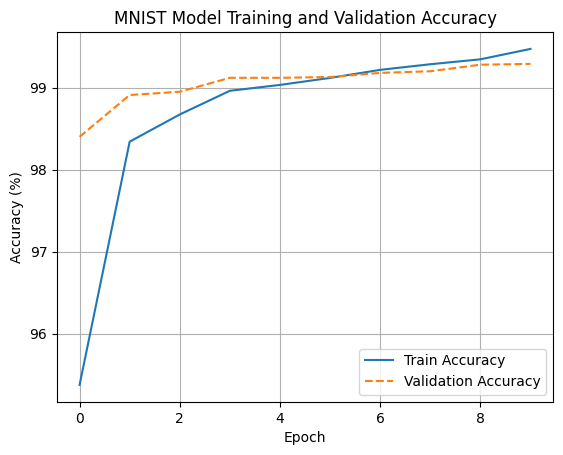

In [28]:
# Accuracy. Compare against CNNs/CNN_MNIST.ipynb, which trained everything from
# scratch: similar accuracy, a fraction of the training.
plt.plot(mnist_train_acc, label='Train Accuracy');
plt.plot(mnist_val_acc ,'--', label='Validation Accuracy');
plt.title('MNIST Model Training and Validation Accuracy');
plt.xlabel('Epoch');
plt.ylabel('Accuracy (%)');
plt.legend();
plt.grid(True);
plt.show();

In [29]:
## Checking if the models weights are same

for target,source in zip(mnist_model_trained.conv.parameters(), letters_model.conv.parameters()):
  if torch.equal(target.data,source.data):
    print("Target and Source are equal !!")
  else: print("Target and Source are not equal!!")

Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
Target and Source are equal !!
